In [1]:
import jax
import flax
import optax
from jax import lax, random, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
from tqdm.auto import tqdm

config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true' # default is true, 90% of GPU VRAM preallocated

Poisson equation $\nabla^2 p = b$

The p and b data in cell_center_data is the exact same as the p and b in the parent dataset except the boundaries are stripped.

In this dataset, we should use Homogeneous Dirichlet Boundary Condition ($p = 0$).

$b$ is the source, $p$ is the pressure simulation ground truth, $\eta$ (eta) represents the geometric boundary mask of the solid obstacles where 0 means fluid, 1.0 means boundary.

This dataset is a simplier version of a bigger stokes flow dataset because we remove $u$ and $v$, where $b = \frac{\rho}{\Delta t} \nabla \cdot \mathbf{u}^*$

We solve the pressure Poisson equation here to predict $p$, meaning we want to learn the mapping $(b, \eta) \rightarrow p$ in a single forward pass.
For the physics loss function, we do $\nabla^2 p_{pred} = b$. For evaluation, we compare $p_{pred}$ with the simulation $p_{sim}$. We can add both into the loss function actually.

In [ ]:
T, S, G = 10, 10, 20
DATA_DIR = Path.cwd().parent.parent / "data" / "poisson-solver" / "T10_data"

p_file = DATA_DIR / "cell_center_data" / "p" / f"dxdy_960x512_p_T{T}_S{S}_G{G}.npy"
b_file = DATA_DIR / "cell_center_data" / "b" / f"dxdy_960x512_b_T{T}_S{S}_G{G}.npy"
eta_file = DATA_DIR / "eta" / f"dxdy_960x512_eta_T{T}_S{S}_G{G}.npy"

In [3]:
p_grid = np.load(p_file)
b_grid = np.load(b_file)
eta_grid = np.load(eta_file)[1:-1, 1:-1]

L = 1.0e-6
x_coords = np.linspace(0, 960 * L, 960)
y_coords = np.linspace(0, 512 * L, 512)
X, Y = np.meshgrid(x_coords, y_coords, indexing='ij')

B_SCALE_FACTOR = 1e11

x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))
p_sim = jnp.array(p_grid.reshape(-1, 1))
b = jnp.array((b_grid / B_SCALE_FACTOR).reshape(-1, 1))
eta = jnp.array(eta_grid.reshape(-1, 1))

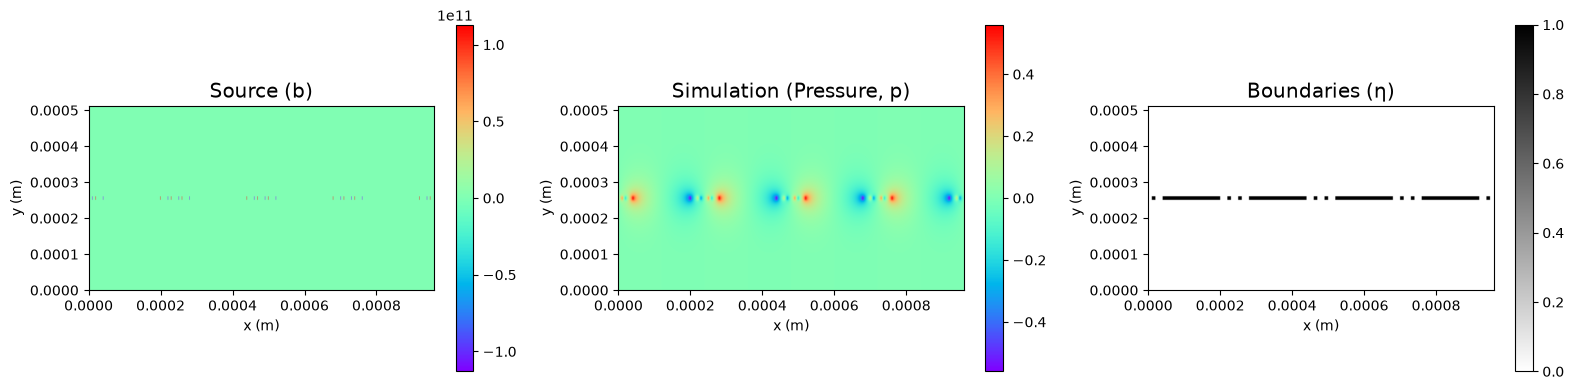

In [4]:
L = 1.0e-6
l_x = L * 960
l_y = L * 512
ext = [0, l_x, 0, l_y]

fig = plt.figure(figsize=(16, 4))

ax1 = fig.add_subplot(1, 3, 1)
s_plot = b_grid.T
mesh1 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Source (b)', fontsize='x-large')

ax2 = fig.add_subplot(1, 3, 2)
s_plot = p_grid.T
mesh2 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
plt.colorbar(mesh2)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Simulation (Pressure, p)', fontsize='x-large')

ax3 = fig.add_subplot(1, 3, 3)
s_plot = eta_grid.T
mesh3 = plt.imshow(s_plot, interpolation='bilinear', origin='lower', cmap='binary', extent=ext, aspect=1.)
plt.colorbar(mesh3)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Boundaries (\u03B7)', fontsize='x-large')

plt.tight_layout()
plt.show()

In [5]:
# Define physical outer boundaries
x_l, x_u = 0.0, 960.0 * 1e-6
y_l, y_u = 0.0, 512.0 * 1e-6

# Extract Outer Walls (Dirichlet Boundary Conditions)
bc_wall = ((x == x_l) | (x == x_u) | (y == y_l) | (y == y_u)).flatten()
x_wall, y_wall = x[bc_wall], y[bc_wall]

# Isolate Active Sources (avoiding outer walls)
b_flat = jnp.abs(b).flatten()
source_mask = (b_flat > 1e-4) & (~bc_wall)
source_indices = jnp.where(source_mask)[0]

# Extract Sifter Obstacles (Neumann)
# Exclude the active sources from the Neumann boundary condition
eta_flat = eta.flatten()
bc_sifter = (eta_flat == 1.0) & (~bc_wall) & (~source_mask)
x_sifter, y_sifter = x[bc_sifter], y[bc_sifter]

# Empty Fluid: No source, no boundary
empty_mask = (b_flat <= 1e-4) & (eta_flat == 0.0) & (~bc_wall)
empty_indices = jnp.where(empty_mask)[0]

print("--- Single Sample Boundary Breakdown ---")
print(f"Outer Wall (Dirichlet) Points : {x_wall.shape[0]}")
print(f"Sifter Wall (Neumann) Points  : {x_sifter.shape[0]}")
print(f"Active Source Interior Points : {source_indices.shape[0]}")
print(f"Empty Fluid Interior Points   : {empty_indices.shape[0]}")

--- Single Sample Boundary Breakdown ---
Outer Wall (Dirichlet) Points : 2940
Sifter Wall (Neumann) Points  : 6960
Active Source Interior Points : 240
Empty Fluid Interior Points   : 481380


In [6]:
# Network Architecture Setup
M = 1024 
hidden_layers = [512, 512, 512, 512] 
total_features = sum(hidden_layers)

rff_key = jax.random.PRNGKey(99)
B_matrix_base = jax.random.normal(rff_key, (2, M)) 

class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix_base: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):
        # Tikhonov regularization parameter
        self.param('raw_tik', nn.initializers.constant(-4.0), (1,))
        
        # Physical Boundaries for Normalization
        x_l, x_u = 0.0, 960.0 * 1e-6
        y_l, y_u = 0.0, 512.0 * 1e-6
        
        x_norm = 2.0 * (x_in - x_l) / (x_u - x_l) - 1.0
        y_norm = 2.0 * (y_in - y_l) / (y_u - y_l) - 1.0
        
        sigma = 7.0 
        v_coords = jnp.concatenate([x_norm, y_norm], axis=-1)
        proj = 2.0 * jnp.pi * jnp.dot(v_coords, self.B_matrix_base * sigma)
        h_rff = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)], axis=-1)
        
        all_features = [] 
        h = h_rff

        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
            h = nn.tanh(h) 
            all_features.append(h)
            
        return jnp.concatenate(all_features, axis=-1)

model = FeatureExtractor(
    hidden_layers=hidden_layers, 
    B_matrix_base=B_matrix_base 
)

# Initialize network parameters
key = jax.random.PRNGKey(0)
dummy_x = jnp.array([0.0])
dummy_y = jnp.array([0.0])
params = model.init(key, dummy_x, dummy_y)

def get_f(params, x_val, y_val):
    return model.apply(params, x_val, y_val)

def get_f_dir(params, x_val, y_val):
    f_y = jacfwd(get_f, argnums=2)(params, x_val, y_val)
    f_xx = jacfwd(jacfwd(get_f, argnums=1), argnums=1)(params, x_val, y_val)
    f_yy = jacfwd(jacfwd(get_f, argnums=2), argnums=2)(params, x_val, y_val)
    
    f_y = jnp.squeeze(f_y, axis=-1)
    f_xx = jnp.squeeze(f_xx, axis=(-1, -2))
    f_yy = jnp.squeeze(f_yy, axis=(-1, -2))
    
    return f_y, f_xx, f_yy

f_spatial_vmap = vmap(get_f, in_axes=(None, 0, 0))
f_dir_spatial_vmap = vmap(get_f_dir, in_axes=(None, 0, 0))

print(f"Model initialized. Total extracted features per point: {total_features}")

Model initialized. Total extracted features per point: 2048


In [7]:
chunk_size = 256

def get_f_chunk(params, x_val, y_val, start_idx, end_idx):
    f = model.apply(params, x_val, y_val)
    return lax.dynamic_slice(f, (start_idx,), (end_idx - start_idx,))

def get_f_dir_chunk(params, x_val, y_val, start_idx, end_idx):
    f_y = jacfwd(get_f_chunk, argnums=2)(params, x_val, y_val, start_idx, end_idx)
    f_xx = jacfwd(jacfwd(get_f_chunk, argnums=1), argnums=1)(params, x_val, y_val, start_idx, end_idx)
    f_yy = jacfwd(jacfwd(get_f_chunk, argnums=2), argnums=2)(params, x_val, y_val, start_idx, end_idx)
    
    f_y = jnp.squeeze(f_y, axis=-1)
    f_xx = jnp.squeeze(f_xx, axis=(-1, -2))
    f_yy = jnp.squeeze(f_yy, axis=(-1, -2))
    
    return f_y, f_xx, f_yy

f_chunk_spatial_vmap = vmap(get_f_chunk, in_axes=(None, 0, 0, None, None))
f_dir_chunk_spatial_vmap = vmap(get_f_dir_chunk, in_axes=(None, 0, 0, None, None))

In [8]:
def get_u(params, x_val, y_val, w_current):
    f = model.apply(params, x_val, y_val)
    return jnp.dot(f, w_current) 

def get_u_dir(params, x_val, y_val, w_current):
    u_y = jacfwd(get_u, argnums=2)(params, x_val, y_val, w_current)
    u_xx = jacfwd(jacfwd(get_u, argnums=1), argnums=1)(params, x_val, y_val, w_current)
    u_yy = jacfwd(jacfwd(get_u, argnums=2), argnums=2)(params, x_val, y_val, w_current)
    
    u_y = jnp.squeeze(u_y)
    u_xx = jnp.squeeze(u_xx)
    u_yy = jnp.squeeze(u_yy)
    
    return u_y, u_xx, u_yy

u_spatial_vmap = vmap(get_u, in_axes=(None, 0, 0, None))
u_dir_spatial_vmap = vmap(get_u_dir, in_axes=(None, 0, 0, None))

In [9]:
@jax.jit(static_argnames=['total_features', 'chunk_size'])
def update_direct_solve(params, x_pde, y_pde, b_pde, x_wall, y_wall, x_sifter, y_sifter, total_features, chunk_size, tik_reg):
    A_chunks = []
    B_SCALE_FACTOR = 1e11
    L_SCALE = 1e-6 
    
    W_PDE = 1.0
    W_WALL = 100.0
    W_SIFTER = 1.0 
    
    for start_idx in range(0, total_features, chunk_size):
        end_idx = min(start_idx + chunk_size, total_features)
        
        # PDE Block
        _, f_xx, f_yy = f_dir_chunk_spatial_vmap(params, x_pde, y_pde, start_idx, end_idx)
        A_pde_chunk = ((f_xx + f_yy) / B_SCALE_FACTOR) * W_PDE
        
        # Boundary Blocks
        A_wall_chunk = f_chunk_spatial_vmap(params, x_wall, y_wall, start_idx, end_idx) * W_WALL
        
        f_y_sifter, _, _ = f_dir_chunk_spatial_vmap(params, x_sifter, y_sifter, start_idx, end_idx)
        A_sifter_chunk = (f_y_sifter * L_SCALE) * W_SIFTER
        
        # Matrix A (No simulation data included)
        A_chunk = jnp.vstack([A_pde_chunk, A_wall_chunk, A_sifter_chunk])
        A_chunks.append(A_chunk)
        
    A = jnp.hstack(A_chunks)
    
    # Right Hand Side (No simulation data included)
    b_wall = jnp.zeros((x_wall.shape[0], 1))
    b_sifter = jnp.zeros((x_sifter.shape[0], 1))
    b_pde_weighted = b_pde * W_PDE 
    
    b_RHS = jnp.vstack([b_pde_weighted, b_wall, b_sifter])
    
    AtA = A.T @ A + tik_reg * jnp.eye(total_features)
    AtB = A.T @ b_RHS
    
    return jnp.linalg.solve(AtA, AtB)

def full_forward_and_loss(params, x_pde, y_pde, b_pde, p_sim_pde, x_wall, y_wall, x_sifter, y_sifter, total_features, chunk_size):
    # raw_tik = params['params']['raw_tik'][0]
    # tik_reg = 10.0 ** raw_tik

    tik_reg = 1e-4  
    
    # The solver computes weights using purely physics and boundaries
    w_current = update_direct_solve(params, x_pde, y_pde, b_pde, x_wall, y_wall, x_sifter, y_sifter, total_features, chunk_size, tik_reg)
    
    B_SCALE_FACTOR = 1e11
    L_SCALE = 1e-6
    
    # The outer optimizer evaluates the prediction against the simulation data
    p_pred = jnp.squeeze(u_spatial_vmap(params, x_pde, y_pde, w_current))
    loss_sim = jnp.mean((p_pred - jnp.squeeze(p_sim_pde)) ** 2)
    
    _, u_xx, u_yy = u_dir_spatial_vmap(params, x_pde, y_pde, w_current)
    pde_residual = ((u_xx + u_yy) / B_SCALE_FACTOR) - jnp.squeeze(b_pde)
    loss_pde = jnp.mean(pde_residual ** 2)
     
    p_wall = jnp.squeeze(u_spatial_vmap(params, x_wall, y_wall, w_current))
    loss_wall = jnp.mean(p_wall ** 2)
    
    u_y_sifter, _, _ = u_dir_spatial_vmap(params, x_sifter, y_sifter, w_current)
    loss_sifter = jnp.mean((u_y_sifter * L_SCALE) ** 2)
    
    # Increase the NN gradient penalty on the walls
    total_loss = loss_sim + loss_pde + (10.0 * loss_wall) + loss_sifter
    
    return total_loss, (w_current, loss_sim, loss_pde, loss_wall, loss_sifter, tik_reg)

loss_grad_fn = jax.jit(
    jax.value_and_grad(full_forward_and_loss, argnums=0, has_aux=True), 
    static_argnames=['total_features', 'chunk_size']
)

optimizer = optax.adamw(learning_rate=1e-3, weight_decay=1e-4)

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def update_network(params, opt_state, x_pde, y_pde, b_pde, p_sim_pde, x_wall, y_wall, x_sifter, y_sifter, total_features, chunk_size):
    (loss, (w_current, loss_sim, loss_pde, loss_wall, loss_sifter, tik_reg)), grads = loss_grad_fn(
        params, x_pde, y_pde, b_pde, p_sim_pde, x_wall, y_wall, x_sifter, y_sifter, total_features, chunk_size
    )
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    
    return new_params, opt_state, loss, w_current, loss_sim, loss_pde, loss_wall, loss_sifter, tik_reg

In [10]:
# Training Hyperparameters
epochs = 2000
chunk_size = 256
spatial_batch_size = 2000
wall_batch_size = 400
sifter_batch_size = 200

opt_state = optimizer.init(params)
w_final = None 

rng = jax.random.PRNGKey(42)

for epoch in tqdm(range(epochs), desc="Training Single Sample"):
    rng, s_key, e_key, wall_key, sifter_key = jax.random.split(rng, 5)
    
    # Sample Sifter Surfaces (Neumann)
    n_sift_avail = x_sifter.shape[0]
    sift_idx = jax.random.choice(sifter_key, n_sift_avail, shape=(sifter_batch_size,), replace=(n_sift_avail < sifter_batch_size))
    x_sifter_chunk = x_sifter[sift_idx]
    y_sifter_chunk = y_sifter[sift_idx]

    # Sample PDE Field
    n_sources_avail = source_indices.shape[0]
    n_sources = min(1000, n_sources_avail)
    
    s_idx = jax.random.choice(s_key, source_indices, shape=(n_sources,), replace=False)
    e_idx = jax.random.choice(e_key, empty_indices, shape=(spatial_batch_size - n_sources,), replace=False)
    
    pde_idx = jnp.concatenate([s_idx, e_idx])
    x_pde_chunk = x[pde_idx]
    y_pde_chunk = y[pde_idx]
    b_pde_chunk = b[pde_idx]
    p_sim_chunk = p_sim[pde_idx]
    
    # Sample Outer Walls (Dirichlet)
    n_wall_avail = x_wall.shape[0]
    w_idx = jax.random.choice(wall_key, n_wall_avail, shape=(wall_batch_size,), replace=False)
    x_wall_chunk = x_wall[w_idx]
    y_wall_chunk = y_wall[w_idx]
    
    # --- Network Update ---
    params, opt_state, loss, w_current, l_sim, l_pde, l_wall, l_sift, tik = update_network(
        params, opt_state, 
        x_pde_chunk, y_pde_chunk, b_pde_chunk, p_sim_chunk, 
        x_wall_chunk, y_wall_chunk, x_sifter_chunk, y_sifter_chunk,
        total_features, chunk_size
    )
    
    w_final = w_current
    
    if epoch % 100 == 0:
        tqdm.write(f"Epoch {epoch:04d} | Tot: {loss:.2e} | Sim: {l_sim:.2e} | PDE: {l_pde:.2e} | Wall: {l_wall:.2e} | Sift: {l_sift:.2e} | Tik: {tik:.2e}")

Training Single Sample:   0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 0000 | Tot: 3.31e-01 | Sim: 2.97e-01 | PDE: 2.07e-02 | Wall: 1.14e-07 | Sift: 1.33e-02 | Tik: 1.00e-04
Epoch 0100 | Tot: 1.21e-02 | Sim: 1.03e-02 | PDE: 1.06e-03 | Wall: 3.05e-09 | Sift: 7.86e-04 | Tik: 1.00e-04
Epoch 0200 | Tot: 6.58e-03 | Sim: 5.87e-03 | PDE: 3.80e-04 | Wall: 2.84e-09 | Sift: 3.36e-04 | Tik: 1.00e-04
Epoch 0300 | Tot: 4.03e-03 | Sim: 3.64e-03 | PDE: 2.44e-04 | Wall: 1.66e-09 | Sift: 1.47e-04 | Tik: 1.00e-04
Epoch 0400 | Tot: 2.97e-03 | Sim: 2.66e-03 | PDE: 2.05e-04 | Wall: 1.00e-09 | Sift: 1.07e-04 | Tik: 1.00e-04
Epoch 0500 | Tot: 2.67e-03 | Sim: 2.39e-03 | PDE: 1.71e-04 | Wall: 6.41e-10 | Sift: 1.11e-04 | Tik: 1.00e-04
Epoch 0600 | Tot: 2.31e-03 | Sim: 2.10e-03 | PDE: 1.32e-04 | Wall: 9.25e-10 | Sift: 8.14e-05 | Tik: 1.00e-04
Epoch 0700 | Tot: 1.87e-03 | Sim: 1.69e-03 | PDE: 1.09e-04 | Wall: 2.56e-10 | Sift: 7.27e-05 | Tik: 1.00e-04
Epoch 0800 | Tot: 1.44e-03 | Sim: 1.28e-03 | PDE: 9.10e-05 | Wall: 4.10e-10 | Sift: 7.16e-05 | Tik: 1.00e-04
Epoch 0900 | Tot: 1

Evaluating full grid safely in chunks...
Final Single Sample Metrics -> MSE: 4.64e-04 | MAE: 1.69e-02 | RL2: 4.35e-01


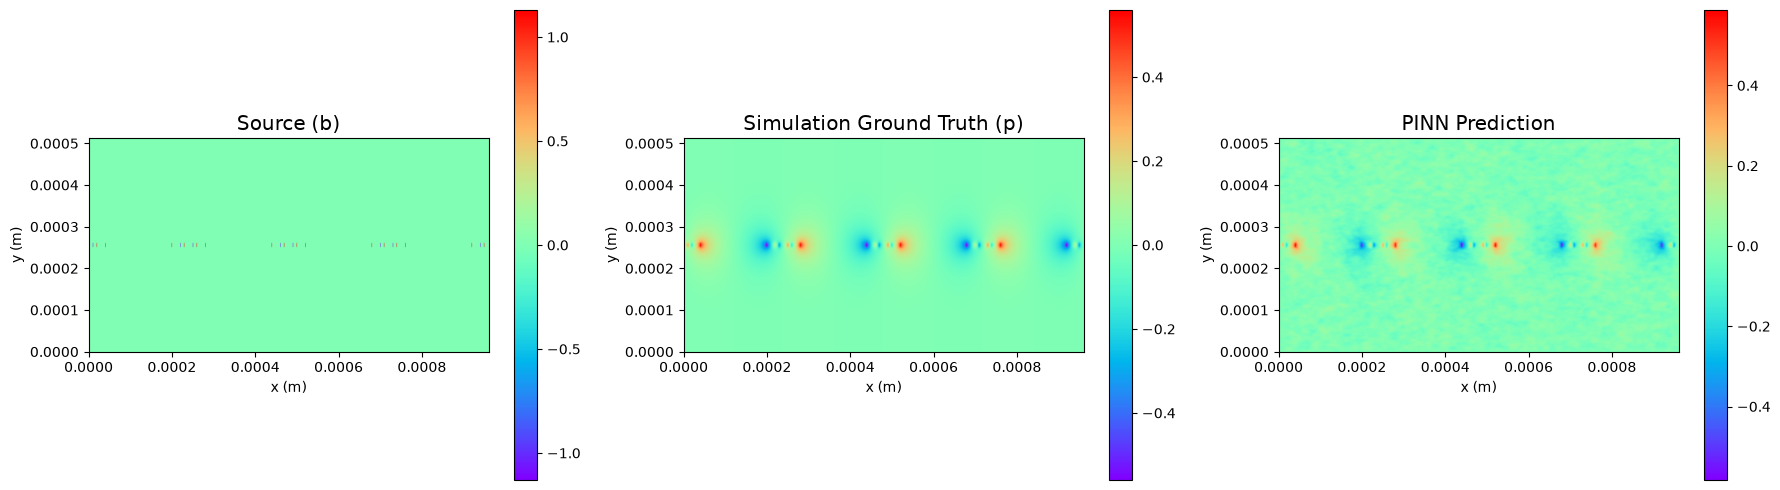

In [11]:
print("Evaluating full grid safely in chunks...")

chunk_size_eval = 10000 
total_points = x.shape[0]
u_pred_list = []

for i in range(0, total_points, chunk_size_eval):
    x_c = x[i : i+chunk_size_eval]
    y_c = y[i : i+chunk_size_eval]
    
    f_chunk = f_spatial_vmap(params, x_c, y_c)
    
    p_pred_chunk = jnp.dot(f_chunk, w_final)
    u_pred_list.append(p_pred_chunk)
    
p_pred = jnp.concatenate(u_pred_list).flatten() 

p_sim_flat = p_sim.flatten()

mse = jnp.mean((p_sim_flat - p_pred)**2)
mae = jnp.mean(jnp.abs(p_sim_flat - p_pred))
rl2 = jnp.linalg.norm(p_sim_flat - p_pred) / jnp.linalg.norm(p_sim_flat)

print(f"Final Single Sample Metrics -> MSE: {mse:.2e} | MAE: {mae:.2e} | RL2: {rl2:.2e}")

# Reshape arrays back to original grid dimensions (960x512)
b_plot = b.reshape(960, 512).T
p_sim_plot = p_sim.reshape(960, 512).T
p_pred_plot = p_pred.reshape(960, 512).T

ext = [0, 960 * 1e-6, 0, 512 * 1e-6]

fig = plt.figure(figsize=(18, 5))

ax1 = fig.add_subplot(1, 3, 1)
mesh1 = ax1.imshow(b_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh1, ax=ax1)
ax1.set_xlabel('x (m)')
ax1.set_ylabel('y (m)')
ax1.set_title('Source (b)', fontsize='x-large')

ax2 = fig.add_subplot(1, 3, 2)
mesh2 = ax2.imshow(p_sim_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh2, ax=ax2)
ax2.set_xlabel('x (m)')
ax2.set_ylabel('y (m)')
ax2.set_title('Simulation Ground Truth (p)', fontsize='x-large')

ax3 = fig.add_subplot(1, 3, 3)
mesh3 = ax3.imshow(p_pred_plot, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh3, ax=ax3)
ax3.set_xlabel('x (m)')
ax3.set_ylabel('y (m)')
ax3.set_title('PINN Prediction', fontsize='x-large')

plt.tight_layout()
plt.show()